# **Misión del proyecto:** "Identificar patrones que determinen si un juego tiene éxito o no para la tienda online Ice"

Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.


## **Paso 1:** Abre el archivo de datos y estudia la información general

  ### Importar las librerias:

In [1]:
# Cargando todas las librerías:
import pandas as pd
import numpy as np
import math
import seaborn as sns

from math import factorial
from scipy import stats as st
from matplotlib import pyplot as plt

### Leer el archivo

In [2]:
df_games=pd.read_csv('/content/games.csv')

### Mostrar la información del archivo y un resumen de lo que contiene:

In [3]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
df_games.sample(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
2708,Lost Planet 2,X360,2010.0,Shooter,0.38,0.23,0.08,0.06,NaN,NaN,NaN
2141,Dance Dance Revolution 2nd ReMIX,PS,1999.0,Simulation,0.00,0.00,0.90,0.06,NaN,NaN,NaN
8811,World Series Baseball 2K3,XB,2003.0,Sports,0.11,0.03,0.00,0.01,89.0,8.6,E
1760,Medal of Honor Heroes 2,PSP,2007.0,Shooter,0.50,0.39,0.02,0.25,69.0,7.3,T
15260,Love Once: Mermaid's Tears,PS3,2011.0,Adventure,0.00,0.00,0.02,0.00,NaN,NaN,NaN
13481,Kimi ni Todoke: Tsutaeru Kimochi,DS,2011.0,Adventure,0.00,0.00,0.05,0.00,NaN,NaN,NaN
16002,Berserk and the Band of the Hawk,PSV,2016.0,Action,0.00,0.00,0.02,0.00,NaN,NaN,NaN
7724,Dead Space 3,PC,NaN,Action,0.02,0.16,0.00,0.02,78.0,6,M
2758,Assassin's Creed: Revelations,PC,2011.0,Action,0.14,0.48,0.00,0.12,80.0,7.4,M
12961,Hi-Octane: The Track Fights Back!,PS,1995.0,Racing,0.03,0.02,0.00,0.00,NaN,NaN,NaN


### Verificar valores ausentes, duplicados, ect.

In [5]:
df_games.isna().sum()

,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
NA_sales,0
EU_sales,0
JP_sales,0
Other_sales,0
Critic_Score,8578
User_Score,6701


In [6]:
df_games.duplicated().sum()

np.int64(0)

**Descripción de lo observado:**

1. Los nombres de las columnas contienen letras tanto en mayúculas como en minúsculas al igual que en los datos del dataset.
2. Los tipos de datos de las columnas "User_Score" y "Year_of_Release" son incorrectos.
3. Se observan valores ausentes en el dataset.
4. No se observan valores duplicados.


## **Paso 2:** Prepara los datos

### Corregir los tipos de datos de las columnas:

In [7]:
# Arreglando los nombres de las columnas:
df_games.columns = df_games.columns.str.lower()

  - Los valores tbd en la columna "user_score" da a entender que aún no se le ha determinado un valor numérico. Se cambiará el tipo de dato de la columna a numérico y estos valores se convertirán en valores ausentes, puesto que aún no se determina ningún valor.

### Convierte los datos en los tipos necesarios.

In [8]:
# convirtiendo los datos:
df_games['user_score']=pd.to_numeric(df_games['user_score'],errors='coerce')

In [9]:
# Trabajando con minúsculas:
df_games['platform']=df_games['platform'].str.lower()
df_games['platform']=df_games['platform'].str.strip()

df_games['genre']=df_games['genre'].str.lower()
df_games['genre']=df_games['genre'].str.strip()


In [10]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,wii,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,nes,1985.0,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,wii,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,wii,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,gb,1996.0,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### Si es necesario, elige la manera de tratar los valores ausentes:

 1. Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.
 2. ¿Por qué crees que los valores están ausentes? Brinda explicaciones posibles.
 3. Presta atención a la abreviatura TBD: significa "to be determined" (a determinar). Especifica cómo piensas manejar estos casos.

In [11]:
# Valores ausentes en "user_score":
df_games[df_games['user_score'].isna()].sample(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
13608,Mechanic Escape,ps3,2012.0,platform,0.00,0.00,0.04,0.00,NaN,NaN,NaN
16253,Bratz: Forever Diamondz,ps2,2006.0,adventure,0.01,0.01,0.00,0.00,NaN,NaN,E
15382,Tsuyo Kiss 2 Portable,psp,2010.0,adventure,0.00,0.00,0.02,0.00,NaN,NaN,NaN
956,Air Combat,ps,1995.0,simulation,0.92,0.33,0.52,0.05,NaN,NaN,NaN
6113,Divinity: Original Sin,ps4,2015.0,role-playing,0.10,0.12,0.02,0.04,NaN,NaN,NaN


  - Los valores ausentes en esta columna representan una relación entre las ventas. Se puede observar que esta relación es que las ventas son menores a 30 millones llegando a ser casi cero.
  - También se puede observar la misma relación en la columna "critic_score". Por ende se reemplazaran los valores nulos con 0 (cero)

In [12]:
# Reemplazando los valores ausentes por 0:
df_games.fillna({'user_score':0,'critic_score':0},inplace=True)

In [13]:
# Valores ausentes en "rating":
df_games[df_games['rating'].isna()].head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,nes,1985.0,platform,29.08,3.58,6.81,0.77,0.0,0.0,NaN
4,Pokemon Red/Pokemon Blue,gb,1996.0,role-playing,11.27,8.89,10.22,1.00,0.0,0.0,NaN
5,Tetris,gb,1989.0,puzzle,23.20,2.26,4.22,0.58,0.0,0.0,NaN
9,Duck Hunt,nes,1984.0,shooter,26.93,0.63,0.28,0.47,0.0,0.0,NaN
10,Nintendogs,ds,2005.0,simulation,9.05,10.95,1.93,2.74,0.0,0.0,NaN


  - Los valores en esta columna son una determinada clasificación de edad, donde:

**E:** Todos pueden jugar.

**E+10:** Todos los mayores de 10 años pueden jugar

**T:** Los adolescentes pueden jugar.

**M:** Las personas maduras (mayores a 17 años) pueden jugar.

**A:** Los adultos pueden jugar.

**RP** Sin clasificar

Sabiendo esto, los valores ausentes en la columna "rating" se reemplazarán por el valor "RP"

In [14]:
# Reemplazando los valores ausentes en la columna "rating" por rp que significa "sin clasificar":
df_games['rating']=df_games['rating'].fillna('RP')

In [15]:
# Valores ausentes en la columna "name":
df_games[df_games['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,gen,1993.0,NaN,1.78,0.53,0.00,0.08,0.0,0.0,RP
14244,NaN,gen,1993.0,NaN,0.00,0.00,0.03,0.00,0.0,0.0,RP


  - En esta columna se observan que los valores ausentes son datos donde las criticas en general son ceros y sus ventas no llegan a los 2 millones. Tomando en cuenta estos datos, se podrian eliminar, pero, en este caso solo se reemplazaran por "unknown" ya que aún así ese número de ventas se puede considerar significativa para cálculos posteriores.
  - También se observa un relación con los valores ausentes en la columna "genre", por ende estos valores se reemplazarán con un valor "otro"

In [16]:
# Reemplazando las filas con valores ausentes en las columnas "name" y "genre":
df_games.fillna({'name':'unknown','genre':'otro'}, inplace=True)

In [17]:
df_games.sample(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
12357,GunGriffon II,sat,1998.0,simulation,0.00,0.00,0.06,0.00,0.0,0.0,RP
10847,Just Dance 2017,wiiu,2016.0,misc,0.03,0.06,0.00,0.01,0.0,0.0,E10+
9131,ArmA II,pc,2009.0,shooter,0.00,0.12,0.00,0.02,77.0,7.5,M
9239,Puyo Puyo!! 20th Anniversary,ds,2011.0,puzzle,0.00,0.00,0.14,0.00,0.0,0.0,RP
1890,Skate 2,x360,2009.0,sports,0.82,0.17,0.01,0.09,84.0,8.0,T


In [18]:
# Valores ausentes en la columna "year_of_release:"
df_games[df_games['year_of_release'].isna()].head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,ps2,NaN,sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,ps2,NaN,sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,wii,NaN,action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,ps2,NaN,fighting,1.57,1.02,0.00,0.41,0.0,0.0,RP
609,Space Invaders,2600,NaN,shooter,2.36,0.14,0.00,0.03,0.0,0.0,RP


  - Los valores ausentes en la columna "year_of_release" se reemplazarán por la moda, es decir, por el año en el cual en una plataforma lanzaron un juego.

In [19]:
# Plataformas donde los valores de la columna "year_of_release" son nulos:
nan= df_games[df_games['year_of_release'].isna()]['platform'].unique()

In [20]:
# Los años de lanzamiento donde un juego fue lanzado en una plataforma:
años_plataforma = df_games[(df_games['platform'].isin(nan) & (~df_games['year_of_release'].isna()))]

In [21]:
# Agrupándo los datos de las plataformas y contando las veces en que se lanzó un juego en esa plataforma:
conteo= años_plataforma.groupby('platform')['year_of_release'].value_counts().reset_index(name='count')

In [22]:
# Agrupando por 'platform' y guardando el valor máximo de "count":
p_max= conteo.groupby('platform')['count'].max().reset_index(name='count')

In [23]:
año=conteo.merge(p_max,on=['platform','count'],how='right')

In [24]:
# Funcion que reemplaza los valores ausentes
def nan(plataforma,año):
  df_games.loc[(df_games['platform']==plataforma) & (df_games['year_of_release'].isna()),'year_of_release']=año
  return df_games

In [25]:
for p in año['platform']:
  for year in año['year_of_release']:
    df_games=nan(p,year)

In [26]:
df_games['year_of_release']=df_games['year_of_release'].astype(int)

In [27]:
df_games.sample(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
4053,One Piece: Grand Battle!,ps,2001,fighting,0.00,0.00,0.46,0.03,0.0,0.0,RP
13748,Chibi Maruko-Chan DS: Maru-Chan no Machi,ds,2009,puzzle,0.00,0.00,0.04,0.00,0.0,0.0,RP
5406,Tiny Tank,ps,1998,action,0.19,0.13,0.00,0.02,0.0,0.0,RP
14104,Secret Files 2: Puritas Cordis,pc,2009,adventure,0.00,0.03,0.00,0.00,64.0,7.1,T
10862,Disney Planes Fire & Rescue,3ds,2014,action,0.01,0.08,0.00,0.01,0.0,0.0,RP
7377,Darkwatch,xb,2005,shooter,0.16,0.05,0.00,0.01,75.0,8.1,M
11144,Viewtiful Joe: Red Hot Rumble,psp,2006,action,0.08,0.00,0.00,0.01,63.0,6.3,T
14304,Dragon's Dogma Online,ps3,2015,role-playing,0.00,0.00,0.03,0.00,0.0,0.0,RP
4182,Super Momotarou Dentetsu DX,snes,1995,misc,0.00,0.00,0.47,0.00,0.0,0.0,RP
11171,Jambo! Safari Animal Rescue,wii,2009,simulation,0.07,0.01,0.00,0.01,0.0,0.0,RP


### Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.

In [28]:
# Calculando las ventas totales:

df_games['total_sales'] = df_games['na_sales'] + df_games['eu_sales'] + df_games['jp_sales'] + df_games['other_sales']
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,nes,1985,platform,29.08,3.58,6.81,0.77,0.0,0.0,RP,40.24
2,Mario Kart Wii,wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,gb,1996,role-playing,11.27,8.89,10.22,1.00,0.0,0.0,RP,31.38


## **Paso 3:** Analiza los datos

### Cantidad de juegos lanzados en diferentes años

In [29]:
# Agrupando por año de lanzamiento para saber la cantidad de juegos que se lanzaron en un mismo año:
games_per_year=df_games.groupby(['year_of_release'])['name'].count()


In [30]:
games_per_year.name='juegos_lanzados'

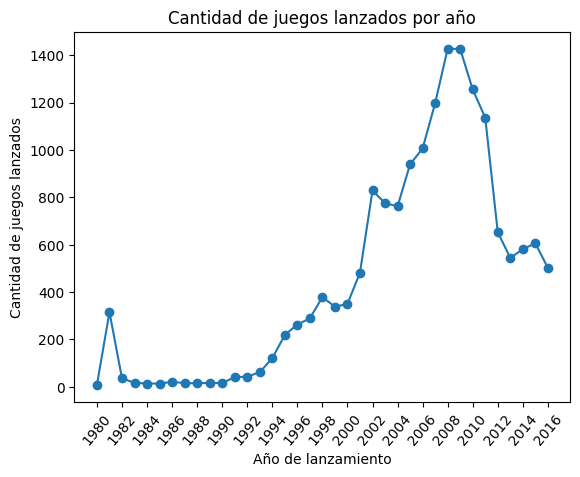

In [31]:
games_per_year.plot(xlabel='Año de lanzamiento',ylabel='Cantidad de juegos lanzados',
                    title='Cantidad de juegos lanzados por año',style='o-',xticks=range(1980,2017,2), rot=50)

plt.show()

  - Se puede observar que los años con más lanzamientos son el 2008 y 2009. Estos son datos significativos.

### Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

In [32]:
# las ventas totales por plataforma y año:

# Agrupando por plataforma y por año de lanzamiento:
# Sumando las ventas totales por plataformas por año:
platform_sales_year= df_games.groupby(['platform','year_of_release'])['total_sales'].sum().sort_values(ascending=False)

In [33]:
# plataformas con las mayores ventas:
# Afrupando las plataformas y sumando los totales de ventas:
total_sales_per_plat=df_games.groupby(['platform'])['total_sales'].sum().sort_values(ascending=False).reset_index()

# las 5 plataformas que dominaron el mercado:
top_platforms= total_sales_per_plat.loc[0:4,:]

In [34]:
top_platforms

,platform,total_sales
0,ps2,1255.77
1,x360,971.42
2,ps3,939.65
3,wii,907.51
4,ds,806.12


In [35]:
# distribucion por año de las plataformas top:

# Filtrando solo las pltaformas top:
df_top=df_games[df_games['platform'].isin(top_platforms['platform'])]

# Creando una tabla que contenga las 5 plataformas top:
# Y, a su vez que tambien contenga las ventas en el año:
df_top=df_top.pivot_table(index='year_of_release',columns='platform',values='total_sales',aggfunc='sum').fillna(0)

In [36]:
df_top

platform,ds,ps2,ps3,wii,x360
year_of_release,,,,,
1981,3.34,22.21,8.31,16.33,10.18
1985,0.02,0.00,0.00,0.00,0.00
2000,0.00,39.17,0.00,0.00,0.00
2001,0.00,166.43,0.00,0.00,0.00
2002,0.00,205.38,0.00,0.00,0.00
2003,0.00,184.31,0.00,0.00,0.00
2004,17.27,211.81,0.00,0.00,0.00
2005,130.14,160.66,0.00,0.00,8.25
2006,119.81,103.42,20.96,137.15,51.62


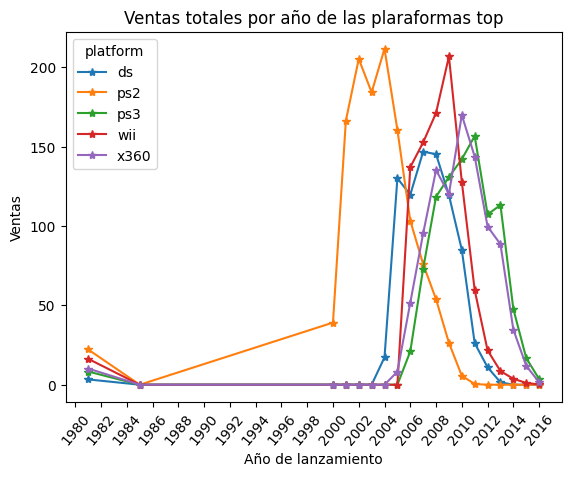

In [37]:
# creando una gráfica que muestre el comportamiento de las plataformas top:

df_top.plot(xticks=range(1980,2017,2),rot=50,style='*-',xlabel='Año de lanzamiento',ylabel='Ventas',
            title='Ventas totales por año de las plaraformas top', legend= True)

plt.show()

En este gráfico se puede observar claramente los años en los que las plataformas top tuvieron su mayor auge.

**PS2** tuvo su auge entre el 2001 y el 2003. Teniendo un pequeño declive en el 2002.

**DS** tuvo su auge entre el 2005 y 2008. Aunque tuvo un declive en el 2006.

**PS3** tuvo su auge en el 2012.

**WII** tuvo su auge en el 2009.

**X360** tuvo su auge en el 2010.

  - **Nota:** Estos datos son una muestra simbolica, hay que tener en cuenta los reemplazos que se realizaron en los años ausentes.

In [38]:
# Plataformas que solian ser populares y ahora no tienen ventas:

#Filtrando las ventas:
## Buscando ventas mayores a 0:
sales_filter= df_games[df_games['total_sales']>0]

# De las ventas filtradas se agrupan los datos por plataforma
# Para identificar el último año y el primer año de lanzamientos en esa plataforma:

#Ultimo año en el que se lanzo un juego en una plataforma:
last_year=sales_filter.groupby('platform')['year_of_release'].max()

# Primer año en el que se lanzo un juego en una plataforma:
first_year=sales_filter.groupby('platform')['year_of_release'].min()

In [39]:
last_year.head()

,year_of_release
platform,
2600,1989
3do,1995
3ds,2016
dc,2008
ds,2013


In [40]:
first_year.head()

,year_of_release
platform,
2600,1980
3do,1994
3ds,1981
dc,1998
ds,1981


In [41]:
# Buscando plataformas que ya no tienen ventas:
platforms_missing=last_year[last_year<2015].reset_index()

Para cada plataforma, se identifica el último y primer año en el que tuvo lanzamientos. Para luego así, identificar las plataformas obsoletas. Se eligió el año 2015 como referencia ya que, se necesita realizar un modelo para el 2017.

In [42]:
platforms_missing.sample(5) #Plataformas obsoletas

,platform,year_of_release
1,3do,1995
5,gba,2007
15,sat,1999
17,snes,1999
19,ws,2001


In [43]:
# ¿Cuánto tiempo dura una plataforma en el mercado?
duracion= last_year - first_year
duracion.head()

,year_of_release
platform,
2600,9
3do,1
3ds,35
dc,10
ds,32


In [44]:
# Calculando la vida promedio de las plataformas:
life_mean= duracion.mean().round(1)
print(f'La vida promedio de una pltaforma es de {life_mean} años')

La vida promedio de una pltaforma es de 16.5 años


**Conclusión:**
1. Las plataformas obsoletas son aquellas en las que no se lanzó un juego en 2015.
2. La gráfica de lineas muestra los años en los que las plataformas top tuvieron sus mayores ventas.
3. La vida promedio de una plataforma es de 16.55 años.

**Nota** Se deben tener en cuenta que los datos fueron reemplazados y las conclusiones son basadas en este reemplazo.

###  - Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.
   Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores

  - Si la duración promedio de una plataforma es de 16.5 años, se tomarán los datos a partir del 2000 hasta el 2016. Esto da 16 años de información antes del año 2017. Este periodo de tiempo incluirá tanto a plataformas maduras como a las nuevas. Además permite obtener información de las tendencias recientes sin datos obsoletos. Tambien se debe recordar que el auge de las plataformas con más ventas fue entre ese periodo de tiempo.

In [45]:
# Filtrando los datos para tener un dataset
# que solo contenga los datos de los juegos lanzados en el periodo del 2007 al 2016:
games_model= df_games[(df_games['year_of_release']> 2000) & (df_games['year_of_release']<=2016)]

In [46]:
games_model.sample(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
6658,Atari Anthology,xb,2004,misc,0.19,0.05,0.00,0.01,68.0,0.0,E,0.25
6142,Jackass the Game,ps2,2007,action,0.14,0.11,0.00,0.04,58.0,6.6,M,0.29
9276,Shinobido 2: Tales of the Ninja,psv,2011,action,0.04,0.05,0.02,0.02,0.0,0.0,RP,0.13
6025,Trauma Center: New Blood,wii,2007,simulation,0.22,0.04,0.01,0.02,77.0,8.0,T,0.29
11243,Assassin's Creed Chronicles,ps4,2016,action,0.01,0.05,0.01,0.01,0.0,6.1,T,0.08


### ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.

In [47]:
# Las plataformas rentables son aquellas que tienen un total de ventas mayor a las demás:

# Agrupando por plataforma y sumando su total:
sales_per_platform=games_model.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

sales_per_platform.head()

,total_sales
platform,
ps2,1194.39
x360,961.24
ps3,931.34
wii,891.18
ds,802.76


In [48]:
# Plataformas top para el modelo:
top_modelo=sales_per_platform.head(10).reset_index()

In [49]:
top_modelo

,platform,total_sales
0,ps2,1194.39
1,x360,961.24
2,ps3,931.34
3,wii,891.18
4,ds,802.76
5,ps4,314.14
6,gba,312.81
7,psp,289.53
8,3ds,257.81
9,xb,250.58


In [50]:
# Las plataformas rentables para el modelo:
platfoms_rentables= games_model[games_model['platform'].isin(top_modelo['platform'])]

In [51]:
platfoms_rentables.sample(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
2780,NBA 2K16,ps3,2015,sports,0.45,0.12,0.03,0.13,0.0,4.6,E,0.73
8630,F-Zero: GP Legend,gba,2003,racing,0.11,0.04,0.00,0.00,77.0,8.5,E,0.15
12762,Blade Dancer: Lineage of Light,psp,2006,role-playing,0.05,0.00,0.00,0.00,60.0,6.9,E10+,0.05
4341,Bee Movie Game,ds,2007,action,0.41,0.00,0.00,0.03,58.0,0.0,E,0.44
13544,Heatseeker,psp,2007,action,0.04,0.00,0.00,0.00,49.0,0.0,T,0.04


In [52]:
# Creando un tabla con las plataformas rentables:

tabla_modelo=platfoms_rentables.pivot_table(index='year_of_release',columns='platform',values='total_sales',aggfunc='sum').fillna(0)

In [53]:
tabla_modelo

platform,3ds,ds,gba,ps2,ps3,ps4,psp,wii,x360,xb
year_of_release,,,,,,,,,,
2001,0.00,0.00,61.53,166.43,0.00,0.00,0.00,0.00,0.00,22.26
2002,0.00,0.00,74.16,205.38,0.00,0.00,0.00,0.00,0.00,48.01
2003,0.00,0.00,56.67,184.31,0.00,0.00,0.00,0.00,0.00,55.04
2004,0.00,17.27,77.91,211.81,0.00,0.00,7.06,0.00,0.00,65.42
2005,0.00,130.14,33.86,160.66,0.00,0.00,43.84,0.00,8.25,49.08
2006,0.00,119.81,5.28,103.42,20.96,0.00,55.32,137.15,51.62,10.04
2007,0.00,146.94,3.40,75.99,73.19,0.00,46.93,152.77,95.41,0.55
2008,0.00,145.31,0.00,53.90,118.52,0.00,34.55,171.32,135.26,0.18
2009,0.00,119.54,0.00,26.40,130.93,0.00,37.78,206.97,120.29,0.00


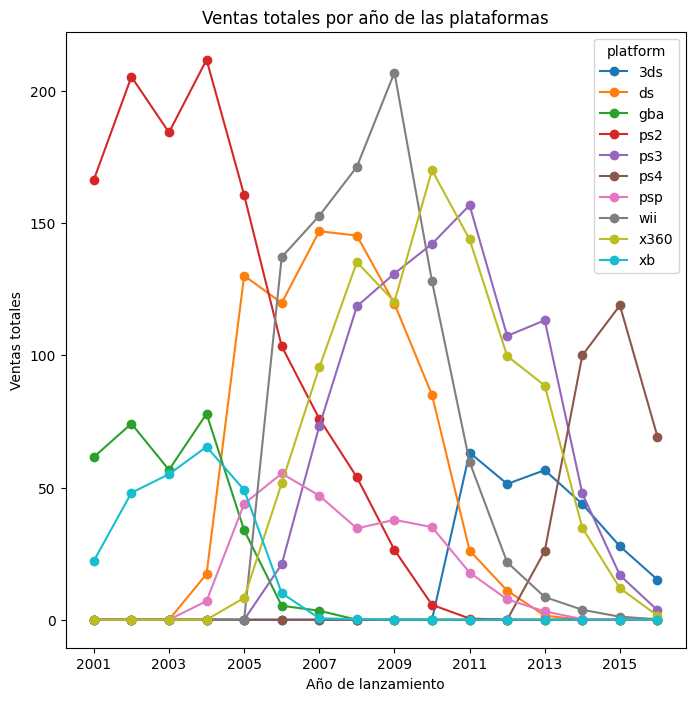

In [54]:
tabla_modelo.plot(xticks=range(2001,2016,2),figsize=(8,8), title='Ventas totales por año de las plataformas',
                  xlabel= 'Año de lanzamiento', ylabel='Ventas totales',style= 'o-')

plt.show()

Se graficaron las plataformas más rentables y se observó que la plataforma ps4 actualmente es la más rentable en el mercado, ya que las demás están obsoletas o simplemente su ciclo de vida está terminando como es el caso de la plataforma 3ds que en la gráfica muestra una tendencia a 0

### Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

In [55]:
 # calculando las ventas promedios de cada plataforma:
sales_mean=games_model.groupby('platform')['total_sales'].mean().sort_values(ascending=False).reset_index(name='sales_mean')

In [56]:
sales_mean.sample(5)

,platform,sales_mean
2,x360,0.780227
11,ds,0.378660
19,psv,0.125431
8,3ds,0.503535
1,ps4,0.801378


In [57]:
print(f'El promedio es: {sales_per_platform.mean()}')

El promedio es: 347.87449999999995


<Axes: ylabel='total_sales'>

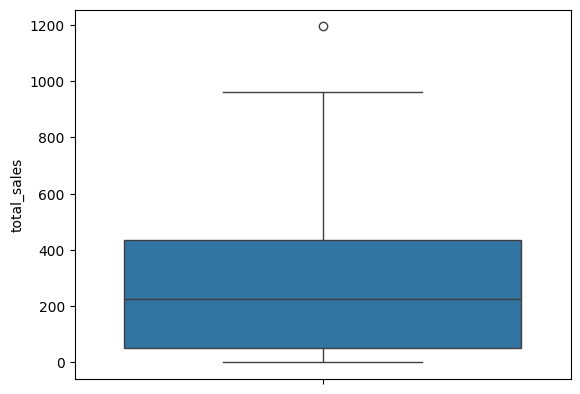

In [58]:
# Gráfica de caja de las ventas totales por plataforma:
sns.boxplot(sales_per_platform)

  - Se puede observar un valor atípico, la mediana de las ventas está alrededor de 200, mientras que el valor medio es 347.87 lo que significa un sesgo positivo hacia la derecha.

### Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.


In [59]:
# Filtrando los datos por ps2:
ps2=games_model[games_model['platform']=='ps2']

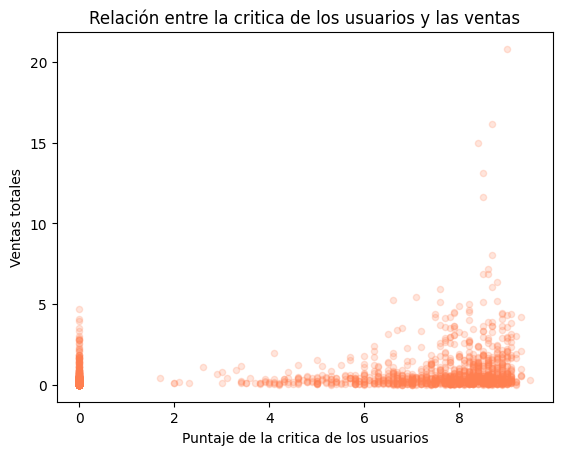

In [60]:
# Grafico de la critica de los usuarios
ps2.plot(kind='scatter',x='user_score',y='total_sales', alpha=0.2,
         title='Relación entre la critica de los usuarios y las ventas',
         xlabel= 'Puntaje de la critica de los usuarios', ylabel='Ventas totales',
          color='coral')

plt.show()

In [61]:
# Calculando la correlación de la critica de los usuarios:
cor_user=ps2['user_score'].corr(ps2['total_sales'])
print(f'La correlación entre la critica de los usuarios y las ventas totales es: {cor_user}')

La correlación entre la critica de los usuarios y las ventas totales es: 0.2605292914395371


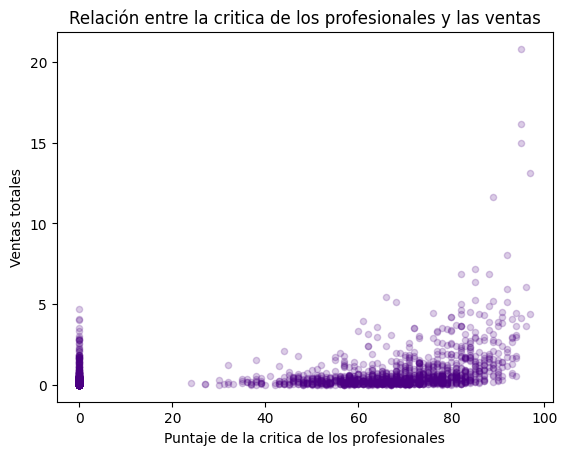

In [62]:
# Grafico de la critica de los profesionales
ps2.plot(kind='scatter',x='critic_score',y='total_sales', alpha=0.2,
         title='Relación entre la critica de los profesionales y las ventas',
         xlabel= 'Puntaje de la critica de los profesionales', ylabel='Ventas totales',
          color='indigo')

plt.show()

In [63]:
# Calculando la correlación de la critica de los profesionales:
cor_user=ps2['critic_score'].corr(ps2['total_sales'])
print(f'La correlación entre la critica de los profesionales y las ventas totales es: {cor_user}')

La correlación entre la critica de los profesionales y las ventas totales es: 0.30081037070065936


  - La correlación entre la critica de los usuarios y las ventas totales es de 0.26, mientras que la correlacion entre la critica de los profesionales y las ventas totales es de 0.30. Lo que indica que la opinión de los profesionales puede influir más que la de los usuarios en la cantidad de ventas.

### Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

In [64]:
# identificando los nombres de los juegos:
juegos=games_model['name'].value_counts(ascending=False).reset_index(name='cant_plataformas')

In [65]:
juegos

,name,cant_plataformas
0,Need for Speed: Most Wanted,12
1,LEGO Marvel Super Heroes,9
2,Ratatouille,9
3,FIFA 14,9
4,Madden NFL 08,8
...,...,...
9400,J-League Pro Soccer Club o Tsukurou! 5,1
9401,Dance Central: Spotlight,1
9402,La Pucelle: Tactics,1
9403,Nostalgia,1


In [66]:
# Eligiendo los primeros 5 juegos con más plataformas:
titulos= juegos.loc[0:4,'name']

In [67]:
# Filtrando los juegos que se lanzaron en más de 1 plataforma:
juegos_multi=juegos[(juegos['cant_plataformas']>1)]

In [68]:
juegos_multi=games_model[games_model['name'].isin(juegos_multi['name'])]

In [69]:
tabla_games=juegos_multi[juegos_multi['name'].isin(titulos)]

In [70]:
tabla_games=tabla_games.pivot_table(index='platform',columns='name',values='total_sales',aggfunc='sum').fillna(0)

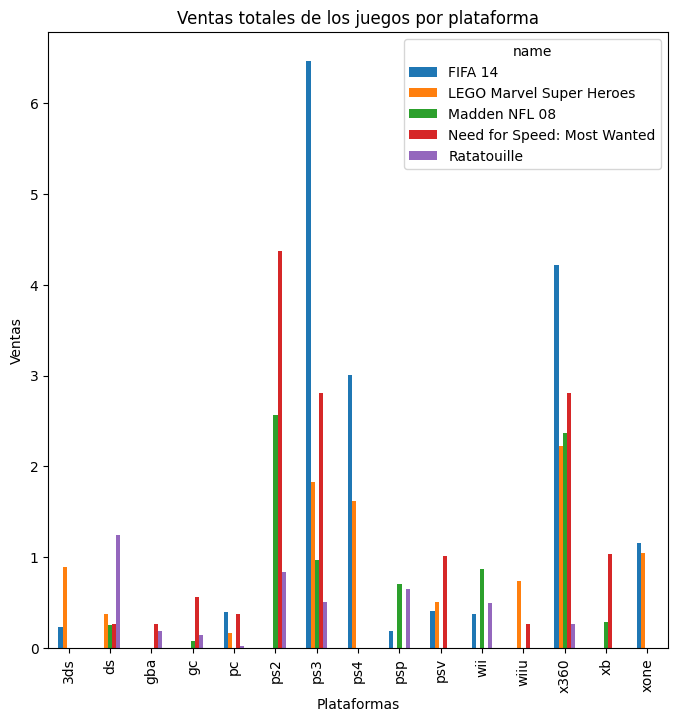

In [71]:
tabla_games.plot(kind='bar',figsize=(8,8),xlabel='Plataformas',ylabel='Ventas',
                 title='Ventas totales de los juegos por plataforma')

plt.show()

### Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

In [120]:
# Juegos por género
genre_games=games_model.groupby('genre')['name'].count().sort_values(ascending=False)

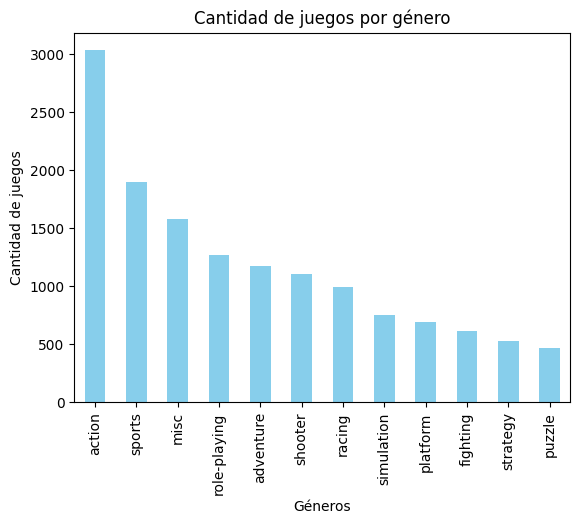

In [121]:
genre_games.plot(kind='bar',xlabel='Géneros',ylabel='Cantidad de juegos',
                 title='Cantidad de juegos por género',color='skyblue')
plt.show()

In [125]:
# Para conocer los géneros más rentables se debe conocer sus ventas totales:

#Agrupando por "genre" y sumando las ventas totales generales:
sales_genre=games_model.groupby('genre')['total_sales'].sum().sort_values(ascending=False).reset_index()

In [126]:
sales_genre.head()

,genre,total_sales
0,action,1492.18
1,sports,1089.68
2,shooter,905.87
3,misc,702.80
4,role-playing,702.17


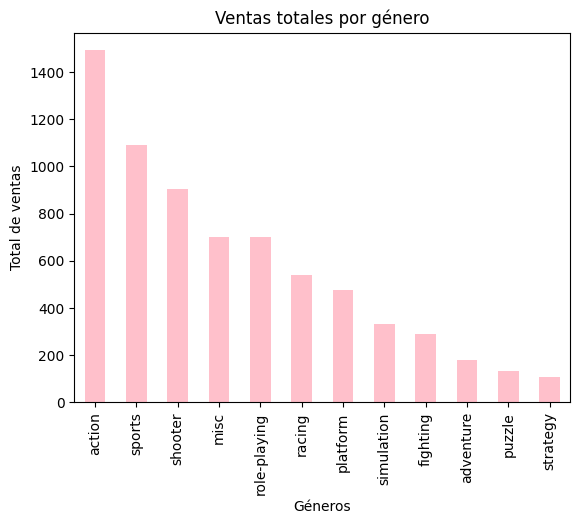

In [132]:
sales_genre.plot(kind='bar',x='genre',xlabel='Géneros',ylabel='Total de ventas',
                 title='Ventas totales por género', legend=False ,color='pink')
plt.show()

In [129]:
mean_genre=games_model.groupby('genre')['total_sales'].mean().sort_values(ascending=False).reset_index(name='sales_mean')

In [130]:
mean_genre

,genre,sales_mean
0,shooter,0.816835
1,platform,0.687313
2,sports,0.574120
3,role-playing,0.552455
4,racing,0.545423
5,action,0.491657
6,fighting,0.477316
7,misc,0.445656
8,simulation,0.440956
9,puzzle,0.287730


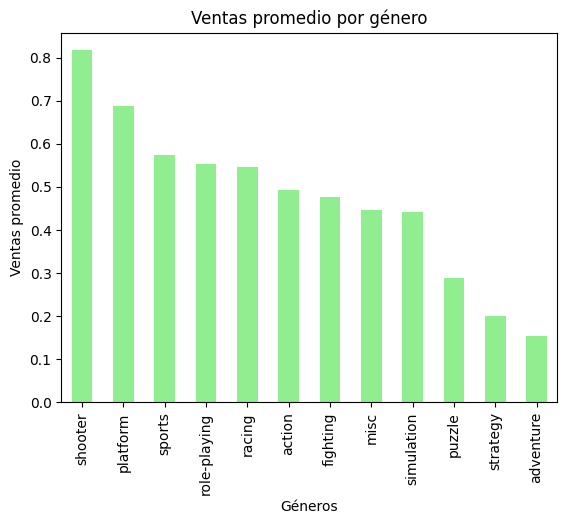

In [131]:
mean_genre.plot(kind='bar',x='genre',xlabel='Géneros',ylabel='Ventas promedio',
                title='Ventas promedio por género',legend=False,color='lightgreen')
plt.show()

   **Conclusión:**

  - Los juegos más populares son action, sports y misc acumulando mayor cantidad de juegos lanzados, lo que indica una alta producción en estos tipos de juegos.
  - Al analizar las ventas se muestran diferencias importantes, los géneros con mayores ventas totales son action, sports y shooter, esto muestra que a pesar de que shooter tiene menos juegos logra destacar con los ingresos.
  - A pesar de que action tiene una gran cantidad de juegos lanzados y también buenas ventas, se puede notar un promedio de ventas por juego más bajo ocupando el puesto número 6. Mientras que shooter, platform y sports logran generar mayores ingresos promedio por juegos.
  - Se puede observar que géneros como puzzle y strategy tienden a tener ventas bajas y pocos juegos lanzados, esto se puede deber a un público más reducido.


En conclusión: Se podría decir que los géneros más rentables son sports y shooter.

## **Paso 4:** Crea un perfil de usuario para cada región

Para cada región (NA, UE, JP) determina:

### Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.

In [133]:
# Agrupando por plataformas y suamando las columnas de las ventas de las regiones:
region_sales=df_games.groupby('platform')[['na_sales','eu_sales','jp_sales']].sum()

In [197]:
# Las 5 plataformas principales por region:

na_sales=region_sales['na_sales'].sort_values(ascending=False).head(5).reset_index()
eu_sales=region_sales['eu_sales'].sort_values(ascending=False).head(5).reset_index()
jp_sales=region_sales['jp_sales'].sort_values(ascending=False).head(5).reset_index()

In [198]:
jp_sales

,platform,jp_sales
0,ds,175.57
1,ps,139.82
2,ps2,139.20
3,snes,116.55
4,3ds,100.67


In [170]:
cuota=region_sales

In [194]:
cuota['cuota_na']=(cuota['na_sales']/cuota['na_sales'].sum())*100
cuota['cuota_eu']=(cuota['eu_sales']/cuota['eu_sales'].sum())*100
cuota['cuota_jp']=(cuota['jp_sales']/cuota['jp_sales'].sum())*100
cuota=cuota.reset_index()

In [214]:
cuota.loc[:,['platform','cuota_na','cuota_eu','cuota_jp']].sample(5)

,platform,cuota_na,cuota_eu,cuota_jp
23,snes,1.390848,0.785261,8.983559
8,gen,0.478154,0.249518,0.208113
2,3ds,1.896487,2.535603,7.759544
16,ps2,13.262008,13.993244,10.729399
18,ps4,2.470044,5.818936,1.230181


**Conslusión:**
 - Las 5 plataformas principales en NA son x360, ps2, wii, ps3 y ds.
 - Las 5 plataformas principales para EU son ps2, ps3, x360, wii y ps.
 - Las 5 plataformas principales para JP son ds, ps, ps2, snes, 3ds.

### Los cinco géneros principales. Explica la diferencia.

In [215]:
# Agrupando por género y sumando las ventas de las regiones:
sales_genre_region=df_games.groupby('genre')[['na_sales','eu_sales','jp_sales']].sum()

In [216]:
sales_genre_region.head()

,na_sales,eu_sales,jp_sales
genre,,,
action,879.01,519.13,161.43
adventure,105.26,63.54,52.30
fighting,223.36,100.33,87.48
misc,407.27,212.74,108.11
otro,1.78,0.53,0.03


In [219]:
genre_na=sales_genre_region['na_sales'].sort_values(ascending=False).head(5).reset_index()
genre_eu=sales_genre_region['eu_sales'].sort_values(ascending=False).head(5).reset_index()
genre_jp=sales_genre_region['jp_sales'].sort_values(ascending=False).head(5).reset_index()

In [223]:
print(f'Los 5 géneros de NA:\n {genre_na}')

Los 5 géneros de NA:
       genre  na_sales
0    action    879.01
1    sports    684.43
2   shooter    592.24
3  platform    445.50
4      misc    407.27


In [226]:
print(f'Los 5 géneros de EU:\n{genre_eu}')

Los 5 géneros de EU:
     genre  eu_sales
0   action    519.13
1   sports    376.79
2  shooter    317.34
3   racing    236.51
4     misc    212.74


In [225]:
print(f'Los 5 géneros de JP:\n{genre_jp}')

Los 5 géneros de JP:
          genre  jp_sales
0  role-playing    355.41
1        action    161.43
2        sports    135.54
3      platform    130.83
4          misc    108.11


**Conclusión:**
 - En Na los géneros más rentables son action, sports, shooter, platform y misc.
 - En EU los géneros más rentables son action, sports, shooter, racing y misc.
 - En JP los géneros más rentables son role-playing, action, sports, platform y misc.

## **Paso 5:** Prueba las siguientes hipótesis:

### Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [232]:
xone=df_games[df_games['platform']=='xone']
pc=df_games[df_games['platform']=='pc']

In [240]:
# Hipótesis nula: "Las calificaciones promedios de los usuarios para las plataformas xone y pc son iguales"
alpha=0.05

hip_nula=st.ttest_ind(xone['user_score'],pc['user_score'])
print(f'El valor p es: {hip_nula.pvalue}')
print('')

if hip_nula.pvalue<alpha:
  print('Se rechaza la hipótesis nula')
else:
  print('No se rechaza la hipótesis nula')

El valor p es: 0.0005833414469972175

Se rechaza la hipótesis nula


- Es una hipótesis bilateral porque lo que interesa es saber si ambas medias son iguales

### Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [239]:
genre_action=df_games[df_games['genre']=='action']
genre_sports=df_games[df_games['genre']=='sports']

In [241]:
# Hipótesis nula: "Las calificaciones promedio de los usuarios para los géneros action y sports son iguales:"
alpha=0.05
hip_nula2=st.ttest_ind(genre_action['user_score'],genre_sports['user_score'])
print(f'El valor p es: {hip_nula2.pvalue}')
print('')

if hip_nula2.pvalue<alpha:
  print('Se rechaza la hipótesis nula')
else:
  print('No se rechaza la hipótesis nula')

El valor p es: 1.1944013786844029e-08

Se rechaza la hipótesis nula


 - Es una hipótesis bilateral porque los que interesa es saber si las medias son iguales o no.

## **Paso 6** Escribe una conclusión general

***Conclusión general:***

El análisis que se le realizó al mercado de videojuegos de la empresa Ice entre los años 2000 y 2016 permitió comprender a fondo cómo se comportan las ventas, las plataformas y los géneros a lo largo del tiempo, y qué factores influyen en el éxito comercial de un juego.

Se descubrió que las plataformas con mayores ventas totales fueron aquellas que dominaron durante un período de auge tecnológico, ps2, x360, ps3, wii y ds. Para construir un modelo predictivo de ventas para el año 2017, se seleccionó el período 2000–2016 como el más representativo y completo.

Se observó que los géneros más populares en términos de cantidad de lanzamientos son Action, Sports y Misc, pero los más rentables por ventas totales son Action, Sports y Shooter. A su vez, los géneros con mayores ventas promedio por juego son Shooter, Platform y Sports.

A nivel regional:
 - Las plataformas más rentables son:
  1. Las 5 plataformas principales en NA son x360, ps2, wii, ps3 y ds.
  2. Las 5 plataformas principales para EU son ps2, ps3, x360, wii y ps.
  3. Las 5 plataformas principales para JP son ds, ps, ps2, snes, 3ds.

 - Los géneros más rentables son:
  1. En Na los géneros más rentables son action, sports, shooter, platform y misc.
  2. En EU los géneros más rentables son action, sports, shooter, racing y misc.
  3. En JP los géneros más rentables son role-playing, action, sports, platform y misc.

En cuanto al análisis de las calificaciones de usuarios y críticos, se observó que la opinión de los profesionales puede influir más que la de los usuarios en la cantidad de ventas.

Finalmente, este análisis permite concluir que las decisiones estratégicas en la empresa Ice deben considerar el tipo de juego, la plataforma de lanzamiento, la región de mercado y la percepción crítica del juego.